<a href="https://colab.research.google.com/github/SateeshPatlolla/Time-Series-Models/blob/main/Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving reviews.csv to reviews.csv
User uploaded file "reviews.csv" with length 43296326 bytes


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM, Activation, Dropout
from sklearn.metrics import mean_squared_error

%matplotlib inline
from IPython.display import display, HTML, display_html
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)


In [9]:
df = pd.read_csv("reviews.csv")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1856294 entries, 0 to 1856293
Data columns (total 2 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   listing_id  int64 
 1   date        object
dtypes: int64(1), object(1)
memory usage: 28.3+ MB


In [11]:
df.head()

,listing_id,date
0,2708,2014-06-09
1,2708,2014-06-23
2,2708,2015-07-25
3,2708,2016-02-01
4,2708,2016-03-20


In [16]:
display(df.describe(percentiles=[0.25,0.5,0.75,0.85,0.95,0.99]))

,listing_id
count,1.856294e+06
mean,3.389921e+17
std,5.052524e+17
min,2.708000e+03
25%,1.663868e+07
50%,3.891006e+07
75%,7.564356e+17
85%,1.034966e+18
95%,1.363355e+18
99%,1.558992e+18


In [14]:
display(df.iloc[:5, :5].dtypes)

,0
listing_id,int64
date,object


In [15]:
df.isnull().sum()

,0
listing_id,0
date,0


### Process Data

In [17]:
df = df.rename(columns={'date':'ds', 'listing_id':'ts'})
_df = df.groupby(by='ds').agg({'ts':'count'})
_df.index = pd.to_datetime(_df.index)
_df = _df.asfreq(freq='1D')
_df = _df.sort_index(ascending=True)
_df = _df.fillna(value = 0)

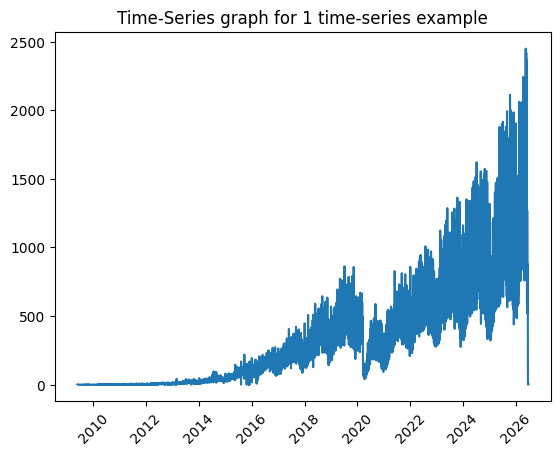

In [19]:
f, ax = plt.subplots(1, 1)
ax.plot(_df['ts'])
ax.set_title('Time-Series graph for 1 time-series example')
ax.tick_params(axis = 'x', rotation = 45)
plt.show()
plt.close()

In [20]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(df, ts):

  rolmean = df[ts].rolling(window=12, center = False).mean()
  rolstd = df[ts].rolling(window=12, center = False).std()
  orig = plt.plot(df[ts], color = 'blue', label = 'Original')
  mean = plt.plot(rolmean, color = 'red', label = 'Rolling Mean')
  std = plt.plot(rolstd, color = 'black', label = 'Rolling Std')

  plt.legend(loc = 'best')
  plt.title('Rolling Mean & Standard Deviation for %s' %(ts))
  plt.xticks(rotation = 45)
  plt.show(block = False)
  plt.close()


  # Perform Dickey-Fuller Test
  # Null Hypothesis (H_0): time-series is not stationary
  # Alternate Hypothesis (H_1): time-series is stationary
  print('Results of Dickey-Fuller Test:')
  dftest = adfuller(df[ts], autolag = 'AIC')
  dfoutput = pd.Series(dftest[0:4], index = ['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
  for key, value in dftest[4].items():
    dfoutput['Critical Value (%s)' % key] = value
  print(dfoutput)

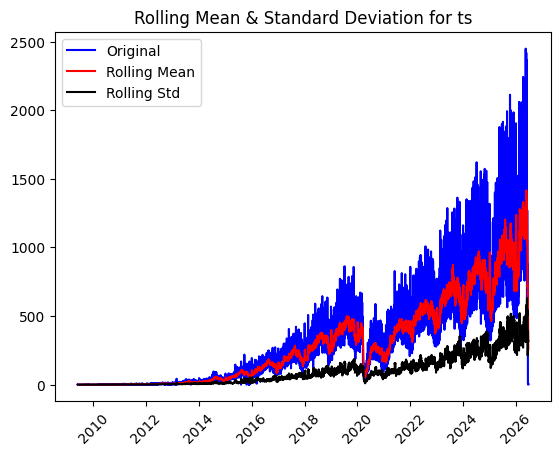

Results of Dickey-Fuller Test:
Test Statistic                   -1.811492
p-value                           0.374771
#Lags Used                       34.000000
Number of Observations Used    6202.000000
Critical Value (1%)              -3.431405
Critical Value (5%)              -2.862006
Critical Value (10%)             -2.567018
dtype: float64


In [21]:
test_stationarity(df = _df, ts = 'ts')

In [27]:
def plot_transformed_data(df,ts,ts_transform):
  f, ax = plt.subplots(1, 1)
  ax.plot(df[ts])
  ax.plot(df[ts_transform])
  ax.set_title('%s and %s time-series graph' %(ts,ts_transform))
  ax.tick_params(axis = 'x', rotation = 45)
  ax.legend([ts, ts_transform])
  plt.show()
  plt.close()
  return


,ts,ts_log,ts_log_moving_avg,ts_moving_avg,ts_log_diff,ts_moving_avg_diff,ts_log_moving_avg_diff,ts_log_ewma,ts_log_ewma_diff
ds,,,,,,,,,
2011-04-01,2.0,0.693147,0.354987,1.857143,0.693147,0.142857,0.338161,0.693147,0.000000
2011-04-25,3.0,1.098612,0.751071,2.428571,-0.287682,0.571429,0.347542,0.905909,0.192703
2011-04-26,1.0,0.000000,0.652050,2.285714,-1.098612,-1.285714,-0.652050,0.573594,-0.573594
2011-04-27,2.0,0.693147,0.751071,2.428571,0.693147,-0.428571,-0.057924,0.608057,0.085090
2011-04-28,1.0,0.000000,0.652050,2.285714,-0.693147,-1.285714,-0.652050,0.461255,-0.461255
2011-04-29,3.0,1.098612,0.808994,2.571429,1.098612,0.428571,0.289618,0.595392,0.503220
2011-05-07,3.0,1.098612,0.741851,2.571429,1.098612,0.428571,0.356761,0.690276,0.408336
2011-05-08,3.0,1.098612,0.668876,2.285714,0.000000,0.714286,0.429736,0.760636,0.337977
2011-05-21,4.0,1.386294,0.782948,2.571429,0.693147,1.428571,0.603346,0.860638,0.525656


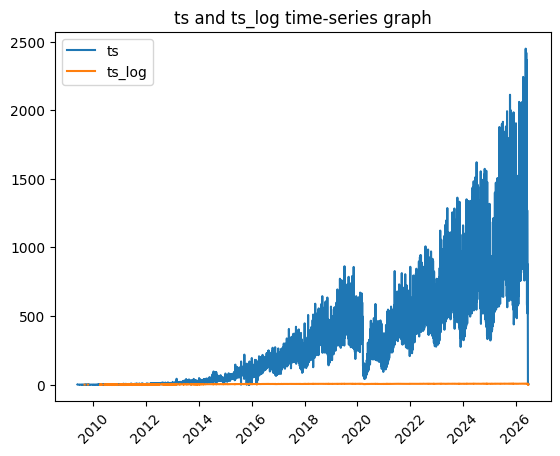

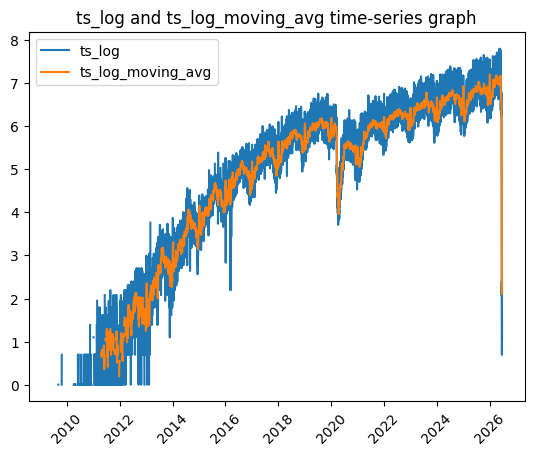

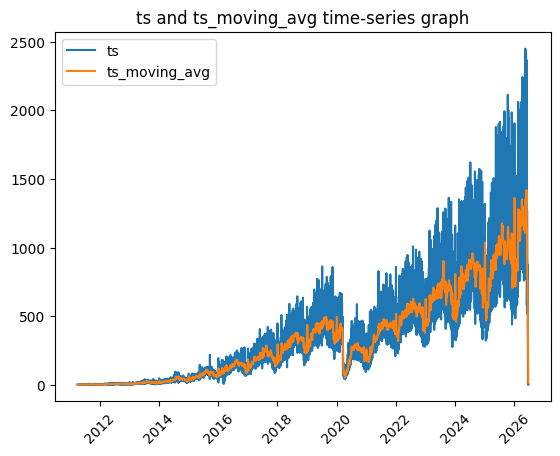

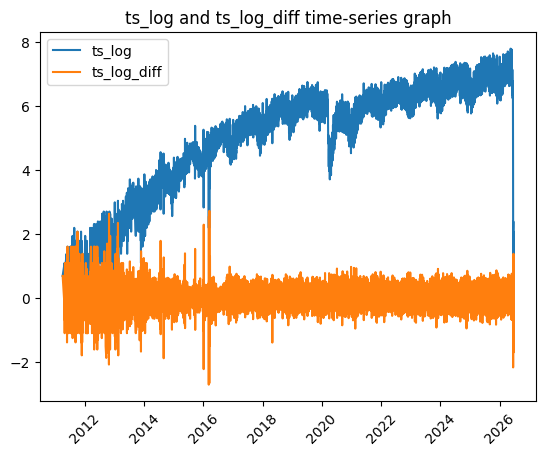

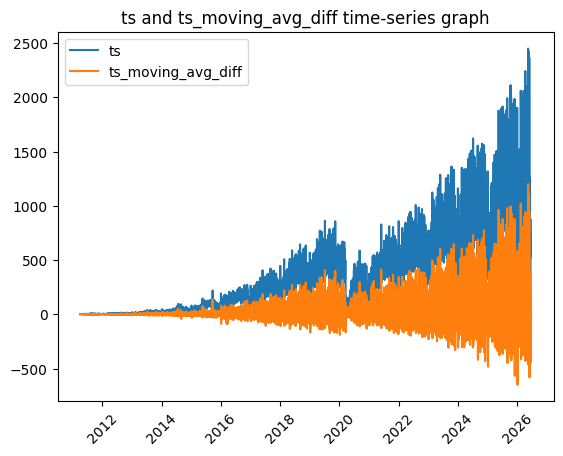

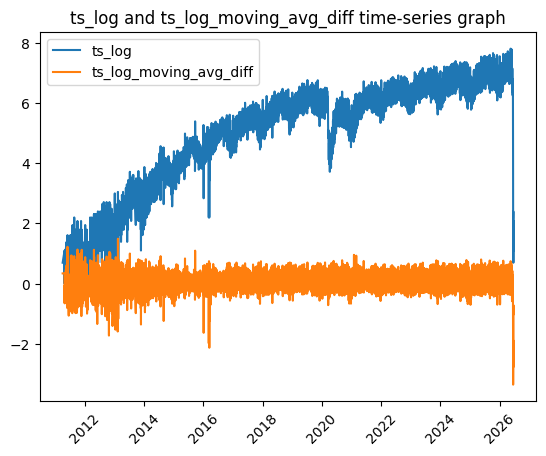

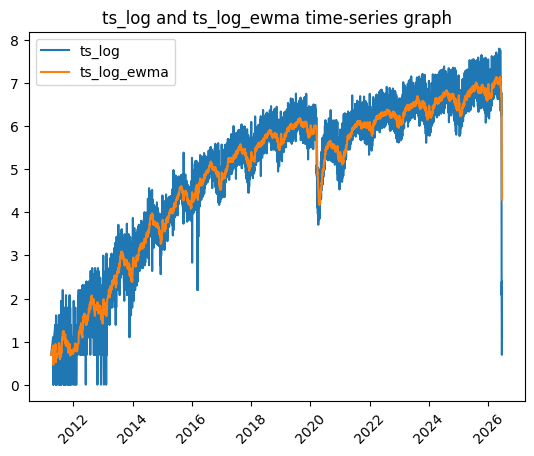

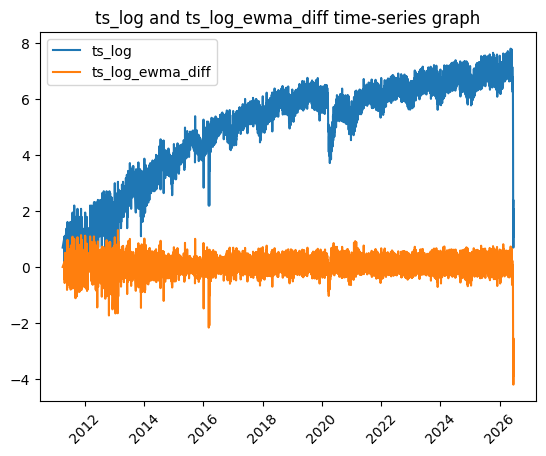

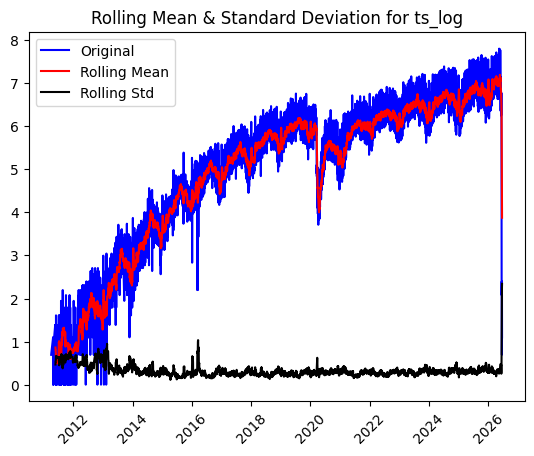

Results of Dickey-Fuller Test:
Test Statistic                   -2.102676
p-value                           0.243440
#Lags Used                       32.000000
Number of Observations Used    5260.000000
Critical Value (1%)              -3.431594
Critical Value (5%)              -2.862090
Critical Value (10%)             -2.567063
dtype: float64


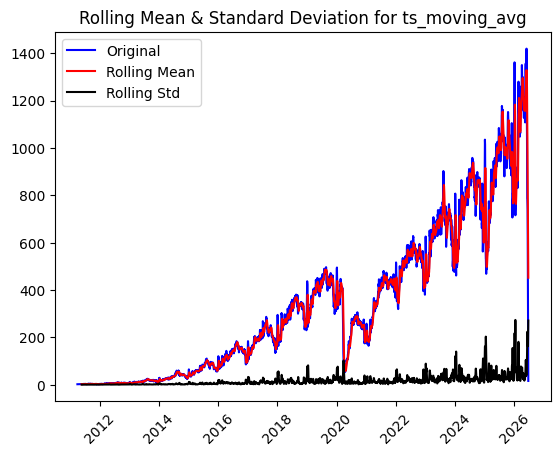

Results of Dickey-Fuller Test:
Test Statistic                   -2.234896
p-value                           0.193825
#Lags Used                       30.000000
Number of Observations Used    5262.000000
Critical Value (1%)              -3.431593
Critical Value (5%)              -2.862089
Critical Value (10%)             -2.567062
dtype: float64


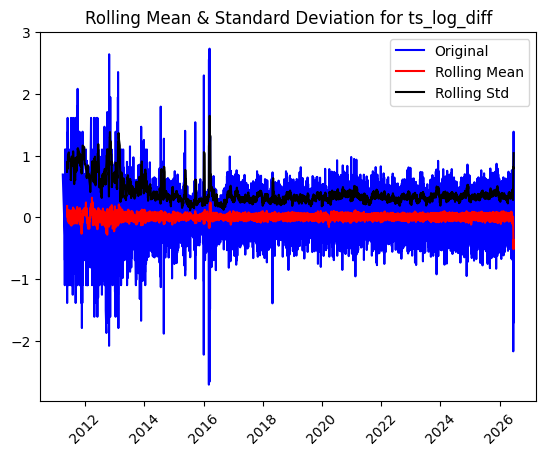

Results of Dickey-Fuller Test:
Test Statistic                -1.046041e+01
p-value                        1.363701e-18
#Lags Used                     3.300000e+01
Number of Observations Used    5.259000e+03
Critical Value (1%)           -3.431594e+00
Critical Value (5%)           -2.862090e+00
Critical Value (10%)          -2.567063e+00
dtype: float64


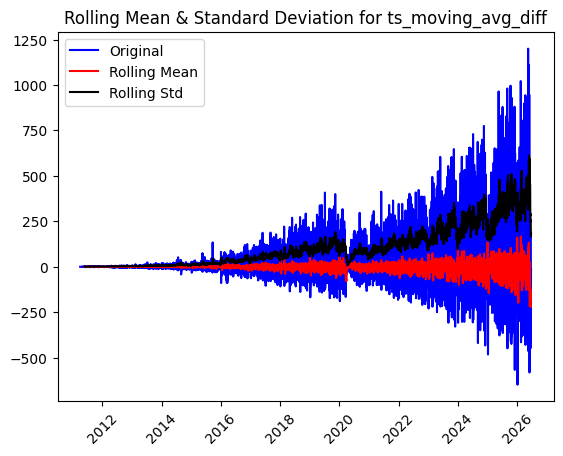

Results of Dickey-Fuller Test:
Test Statistic                -1.055819e+01
p-value                        7.852339e-19
#Lags Used                     3.300000e+01
Number of Observations Used    5.259000e+03
Critical Value (1%)           -3.431594e+00
Critical Value (5%)           -2.862090e+00
Critical Value (10%)          -2.567063e+00
dtype: float64


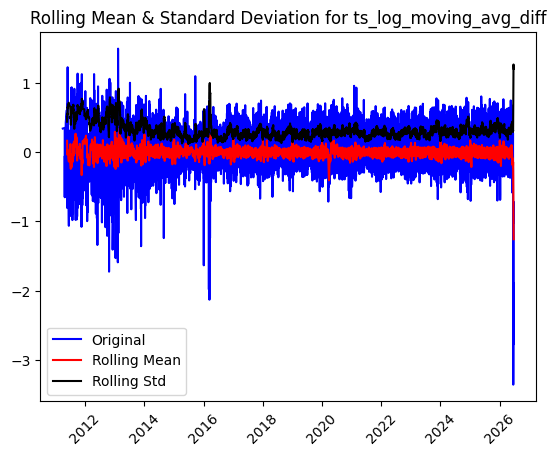

Results of Dickey-Fuller Test:
Test Statistic                -7.593456e+00
p-value                        2.495970e-11
#Lags Used                     3.200000e+01
Number of Observations Used    5.260000e+03
Critical Value (1%)           -3.431594e+00
Critical Value (5%)           -2.862090e+00
Critical Value (10%)          -2.567063e+00
dtype: float64


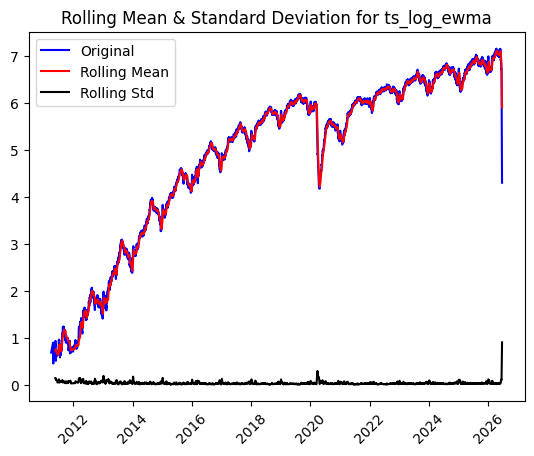

Results of Dickey-Fuller Test:
Test Statistic                   -2.229426
p-value                           0.195739
#Lags Used                       33.000000
Number of Observations Used    5259.000000
Critical Value (1%)              -3.431594
Critical Value (5%)              -2.862090
Critical Value (10%)             -2.567063
dtype: float64


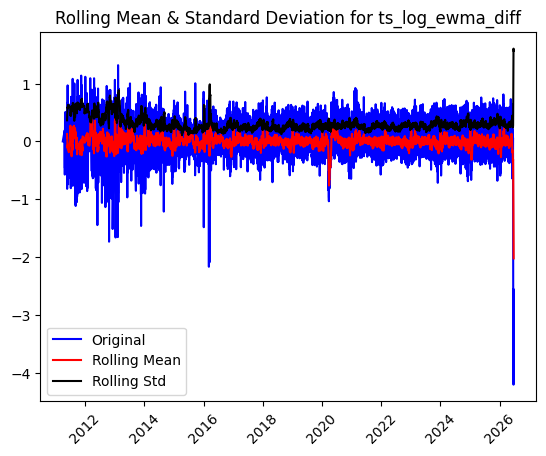

Results of Dickey-Fuller Test:
Test Statistic                -5.928103e+00
p-value                        2.416615e-07
#Lags Used                     3.200000e+01
Number of Observations Used    5.260000e+03
Critical Value (1%)           -3.431594e+00
Critical Value (5%)           -2.862090e+00
Critical Value (10%)          -2.567063e+00
dtype: float64


In [28]:
from ctypes.util import test
_df['ts_log'] = _df['ts'].apply(lambda x: np.log(x))

_df['ts_log_moving_avg'] = _df['ts_log'].rolling(window=7, center=False).mean()

_df['ts_moving_avg'] = _df['ts'].rolling(window=7, center=False).mean()

_df['ts_log_diff'] = _df['ts_log'].diff()

_df['ts_moving_avg_diff'] = _df['ts'] - _df['ts_moving_avg']

_df['ts_log_moving_avg_diff'] = _df['ts_log'] - _df['ts_log_moving_avg']

_df_transform = _df.dropna()

_df_transform['ts_log_ewma'] = _df_transform['ts_log'].ewm(halflife = 7, ignore_na=False, min_periods=0, adjust=True).mean()

_df_transform['ts_log_ewma_diff'] = _df_transform['ts_log'] - _df_transform['ts_log_ewma']

display(_df_transform.head(10))

plot_transformed_data(df = _df, ts = 'ts', ts_transform = 'ts_log')

plot_transformed_data(df = _df, ts = 'ts_log', ts_transform = 'ts_log_moving_avg')

plot_transformed_data(df = _df_transform, ts = 'ts', ts_transform = 'ts_moving_avg')

plot_transformed_data(df = _df_transform, ts = 'ts_log', ts_transform = 'ts_log_diff')

plot_transformed_data(df = _df_transform, ts = 'ts', ts_transform = 'ts_moving_avg_diff')

plot_transformed_data(df = _df_transform, ts = 'ts_log', ts_transform = 'ts_log_moving_avg_diff')

plot_transformed_data(df = _df_transform, ts = 'ts_log', ts_transform = 'ts_log_ewma')

plot_transformed_data(df = _df_transform, ts = 'ts_log', ts_transform = 'ts_log_ewma_diff')

test_stationarity(df = _df_transform, ts = 'ts_log')

test_stationarity(df = _df_transform, ts = 'ts_moving_avg')

test_stationarity(df = _df_transform, ts = 'ts_log_diff')

test_stationarity(df = _df_transform, ts = 'ts_moving_avg_diff')

test_stationarity(df = _df_transform, ts = 'ts_log_moving_avg_diff')

test_stationarity(df = _df_transform, ts = 'ts_log_ewma')

test_stationarity(df = _df_transform, ts = 'ts_log_ewma_diff')



In [29]:
def plot_decomposition(df, ts, trend, seasonal, residual):
  f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize = ( 15, 5), sharex = True)
  ax1.plot(df[ts], label = 'Original')
  ax1.legend(loc = 'best')
  ax1.tick_params(axis= 'x', rotation = 45)

  ax2.plot(df[trend], label = 'Trend')
  ax2.legend(loc = 'best')
  ax2.tick_params(axis= 'x', rotation = 45)

  ax3.plot(df[seasonal], label = 'Seasonality')
  ax3.legend(loc = 'best')
  ax3.tick_params(axis= 'x', rotation = 45)

  ax4.plot(df[residual], label = 'Residuals')
  ax4.legend(loc = 'best')
  ax4.tick_params(axis= 'x', rotation = 45)
  plt.tight_layout()

  plt.suptitle('Trend, Seasonal,  and Residual Decompostion of %s' %(ts),
               x = 0.5, y=1.05, fontsize=18)

  plt.show()
  plt.close()
  return


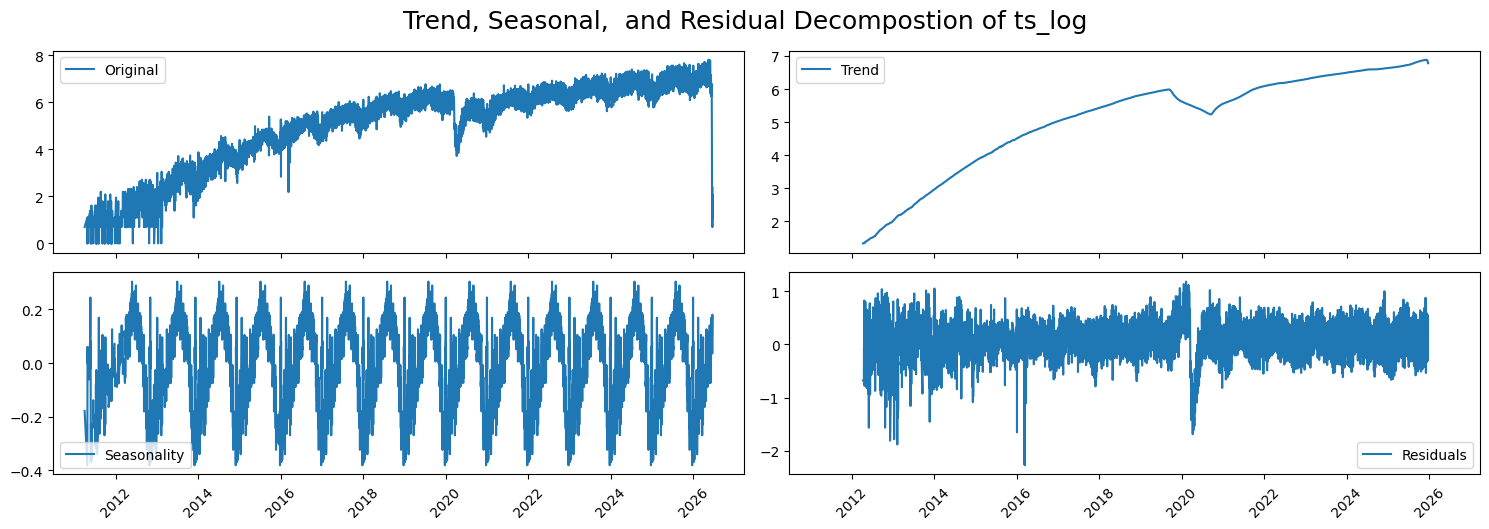

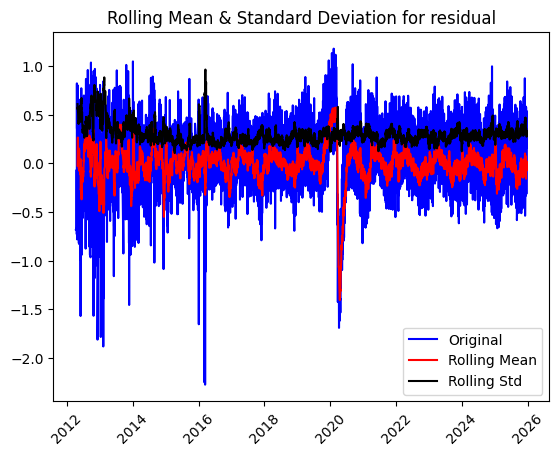

Results of Dickey-Fuller Test:
Test Statistic                -8.057248e+00
p-value                        1.679624e-12
#Lags Used                     3.200000e+01
Number of Observations Used    4.896000e+03
Critical Value (1%)           -3.431686e+00
Critical Value (5%)           -2.862131e+00
Critical Value (10%)          -2.567084e+00
dtype: float64


In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(_df_transform['ts_log'], period = 365)

_df_transform.loc[:, 'trend'] = decomposition.trend
_df_transform.loc[:, 'seasonal'] = decomposition.seasonal
_df_transform.loc[:, 'residual'] = decomposition.resid

plot_decomposition(df = _df_transform, ts = 'ts_log', trend = 'trend', seasonal = 'seasonal', residual = 'residual')
test_stationarity(df = _df_transform.dropna(), ts = 'residual')

In [37]:
from matplotlib.lines import lineStyles
def plot_acf_pacf(df, ts):
  f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
  ax1.plot(lag_acf)
  ax1.axhline(y=0, linestyle = '--', color = 'gray')
  ax1.axhline(y=-1.96/np.sqrt(len(df[ts])), linestyle = '--', color = 'gray')
  ax1.axhline(y=1.96/np.sqrt(len(df[ts])), linestyle='--', color='grey')
  ax1.set_title('Autocorrelation Function')

  ax2.plot(lag_pacf)
  ax2.axhline(y=0, linestyle='--', color='gray')
  ax2.axhline(y=-1.96 / np.sqrt(len(df[ts])), linestyle='--', color='gray')
  ax2.axhline(y=1.96 / np.sqrt(len(df[ts])), linestyle='--', color='grey')
  ax2.set_title('Partial Autocorrelation Function')

  plt.tight_layout()
  plt.show()
  plt.close()
  return

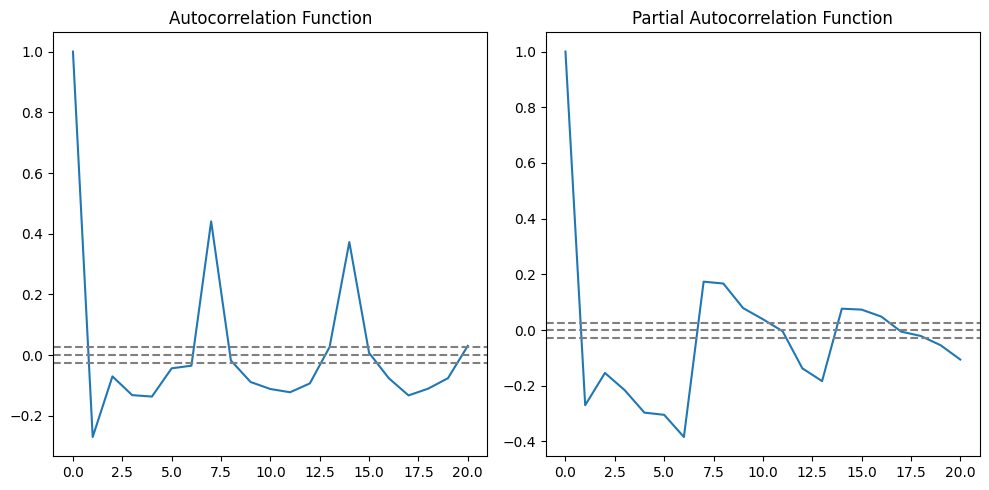

In [38]:
from statsmodels.tsa.stattools import acf, pacf
lag_acf = acf(np.array(_df_transform['ts_log_diff']), nlags = 20)
lag_pacf = pacf(np.array(_df_transform['ts_log_diff']), nlags = 20)

plot_acf_pacf(df = _df_transform, ts = 'ts_log_diff')

In [44]:
def run_arima_model(df, ts, p, d, q):
  from statsmodels.tsa.arima.model import ARIMA
  model = ARIMA(df[ts], order = (p, d, q))
  results_ = model.fit()

  len_results = len(results_.fittedvalues)
  ts_modified = df[ts][-len_results:]

  rss = sum((results_.fittedvalues - ts_modified)**2)
  rmse = np.sqrt(rss/len(df[ts]))

  plt.plot(df[ts])
  plt.plot(results_.fittedvalues, color = 'red')
  plt.title('For ARIMA model (%i, %i, %i) for ts %s, RSS: %.4f, RMSE:%4f' %(p, d, q, ts, rss, rmse))
  plt.show()
  plt.close()
  return

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


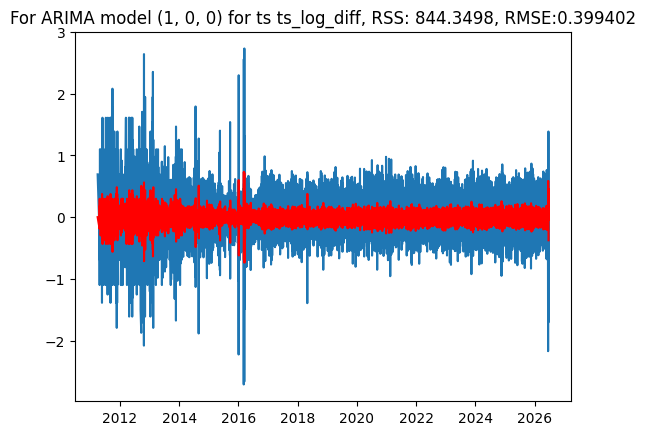

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


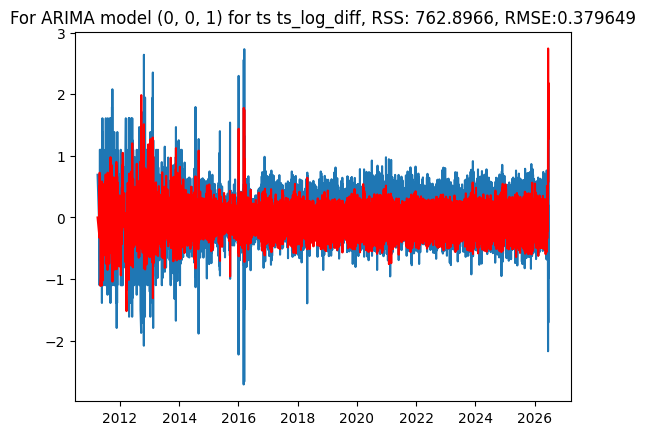

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


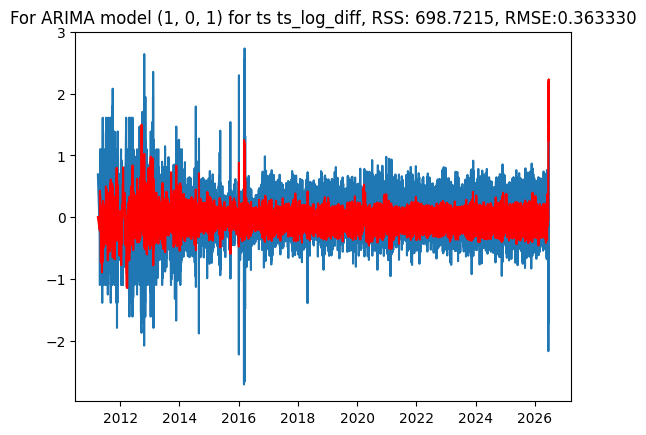

In [45]:
model_AR = run_arima_model(df = _df_transform,
                           ts = 'ts_log_diff',
                           p = 1,
                           d = 0,
                           q = 0)


model_MA = run_arima_model(df = _df_transform,
                           ts = 'ts_log_diff',
                           p = 0,
                           d = 0,
                           q = 1)


model_MA = run_arima_model(df = _df_transform,
                           ts = 'ts_log_diff',
                           p = 1,
                           d = 0,
                           q = 1)

In [ ]:
df.rename(columns={'Precip Type':'PrecipType'}, inplace=True)

In [ ]:
df.PrecipType[df.PrecipType =='rain'] = 0
df.PrecipType[df.PrecipType =='snow'] = 1

<ipython-input-11-0be505ab301c>:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.PrecipType[df.PrecipType =='rain'] = 0
<ipython-input-11-0be505ab301c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [ ]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
PrecipType,143
Temperature (C),0
Apparent Temperature (C),1
Humidity,1
Wind Speed (km/h),1
Wind Bearing (degrees),1
Visibility (km),1
Loud Cover,1


In [ ]:
df.head()

,Formatted Date,Summary,PrecipType,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51


In [ ]:
df.fillna(0, inplace=True)

<ipython-input-12-a616889d5bf1>:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0, inplace=True)


In [ ]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
PrecipType,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [ ]:
df.rename(columns={"Temperature (C)":"Temperature", "Wind Speed (km/h)":"WindSpeed", "Wind Bearing (degrees)":"WindBearings","Visibility (km)":"Visibilty","Loud Cover":"LoudCover","Pressure (millibars)":"Pressure","Apparent Temperature (C)":"ApparentTemperature"},inplace=True)

In [ ]:
df.columns

Index(['Formatted Date', 'Summary', 'PrecipType', 'Temperature',
       'ApparentTemperature', 'Humidity', 'WindSpeed', 'WindBearings',
       'Visibilty', 'LoudCover', 'Pressure'],
      dtype='object')

In [ ]:
df.Summary.unique()

array(['Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Foggy',
       'Breezy and Mostly Cloudy', 'Clear', 'Breezy and Partly Cloudy',
       'Breezy and Overcast', 'Humid and Mostly Cloudy',
       'Humid and Partly Cloudy', 'Windy and Foggy', 'Windy and Overcast',
       'Breezy and Foggy', 'Windy and Partly Cloudy', 'Breezy',
       'Dry and Partly Cloudy', 'Windy and Mostly Cloudy',
       'Dangerously Windy and Partly Cloudy', 'Dry', 'Windy',
       'Humid and Overcast', 'Light Rain', 'Drizzle', 'Windy and Dry',
       'Dry and Mostly Cloudy', 'Breezy and Dry', 'Rain'], dtype=object)

In [ ]:
df.LoudCover.unique()

array([0])

In [ ]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df = df.set_index(pd.DatetimeIndex(df['Formatted Date']))

In [ ]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=['number'])

# Calculate correlation on numeric data
correlation_matrix = numeric_df.corr()

# Display correlation matrix
print(correlation_matrix)

                     PrecipType  Temperature  ApparentTemperature  Humidity  \
PrecipType             1.000000    -0.562620            -0.565207  0.232113   
Temperature           -0.562620     1.000000             0.992629 -0.632255   
ApparentTemperature   -0.565207     0.992629             1.000000 -0.602571   
Humidity               0.232113    -0.632255            -0.602571  1.000000   
WindSpeed             -0.067928     0.008957            -0.056650 -0.224951   
WindBearings          -0.041984     0.029988             0.029031  0.000735   
Visibilty             -0.312875     0.392847             0.381718 -0.369173   
LoudCover                   NaN          NaN                  NaN       NaN   
Pressure               0.009008    -0.005447            -0.000219  0.005454   

                     WindSpeed  WindBearings  Visibilty  LoudCover  Pressure  
PrecipType           -0.067928     -0.041984  -0.312875        NaN  0.009008  
Temperature           0.008957      0.029988   0.39

In [ ]:
df = df.drop(['LoudCover'], axis=1)

<Axes: >

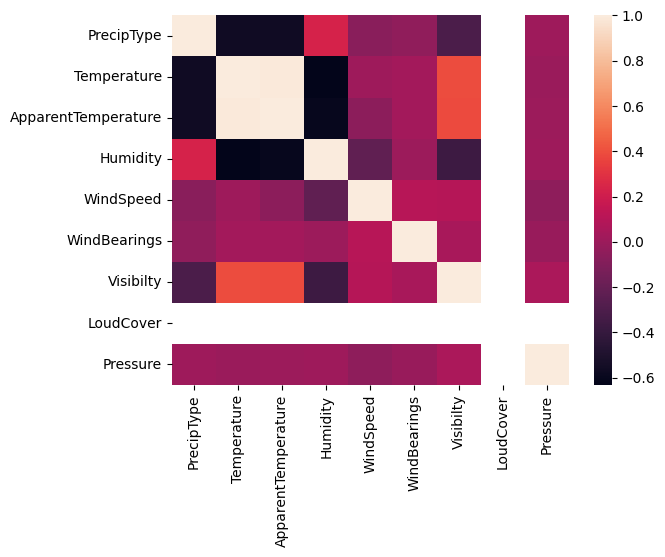

In [ ]:
sns.heatmap(numeric_df.corr())

In [ ]:
df.head()

,Formatted Date,Summary,PrecipType,Temperature,ApparentTemperature,Humidity,WindSpeed,WindBearings,Visibilty,Pressure
Formatted Date,,,,,,,,,,
2006-03-31 22:00:00+00:00,2006-03-31 22:00:00+00:00,Partly Cloudy,0,9.472222,7.388889,0.89,14.1197,251,15.8263,1015.13
2006-03-31 23:00:00+00:00,2006-03-31 23:00:00+00:00,Partly Cloudy,0,9.355556,7.227778,0.86,14.2646,259,15.8263,1015.63
2006-04-01 00:00:00+00:00,2006-04-01 00:00:00+00:00,Mostly Cloudy,0,9.377778,9.377778,0.89,3.9284,204,14.9569,1015.94
2006-04-01 01:00:00+00:00,2006-04-01 01:00:00+00:00,Partly Cloudy,0,8.288889,5.944444,0.83,14.1036,269,15.8263,1016.41
2006-04-01 02:00:00+00:00,2006-04-01 02:00:00+00:00,Mostly Cloudy,0,8.755556,6.977778,0.83,11.0446,259,15.8263,1016.51


In [ ]:
print(len(df.Summary.unique()))
df.Summary.unique()

27


array(['Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Foggy',
       'Breezy and Mostly Cloudy', 'Clear', 'Breezy and Partly Cloudy',
       'Breezy and Overcast', 'Humid and Mostly Cloudy',
       'Humid and Partly Cloudy', 'Windy and Foggy', 'Windy and Overcast',
       'Breezy and Foggy', 'Windy and Partly Cloudy', 'Breezy',
       'Dry and Partly Cloudy', 'Windy and Mostly Cloudy',
       'Dangerously Windy and Partly Cloudy', 'Dry', 'Windy',
       'Humid and Overcast', 'Light Rain', 'Drizzle', 'Windy and Dry',
       'Dry and Mostly Cloudy', 'Breezy and Dry', 'Rain'], dtype=object)

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
labelencoder_X = LabelEncoder()
df.Summary[:] = labelencoder_X.fit_transform(df.Summary[:])

<ipython-input-28-217a850afdf1>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.Summary[:] = labelencoder_X.fit_transform(df.Summary[:])


In [ ]:
df.Summary.unique()

array([19, 17, 18, 12, 3, 6, 5, 4, 13, 15, 23, 25, 2, 26, 0, 11, 24, 7, 9,
       21, 14, 16, 8, 22, 10, 1, 20], dtype=object)

In [ ]:
print(len(df.Summary.unique()))

27


In [ ]:
df.head()

,Formatted Date,Summary,PrecipType,Temperature,ApparentTemperature,Humidity,WindSpeed,WindBearings,Visibilty,Pressure
Formatted Date,,,,,,,,,,
2006-03-31 22:00:00+00:00,2006-03-31 22:00:00+00:00,19,0,9.472222,7.388889,0.89,14.1197,251,15.8263,1015.13
2006-03-31 23:00:00+00:00,2006-03-31 23:00:00+00:00,19,0,9.355556,7.227778,0.86,14.2646,259,15.8263,1015.63
2006-04-01 00:00:00+00:00,2006-04-01 00:00:00+00:00,17,0,9.377778,9.377778,0.89,3.9284,204,14.9569,1015.94
2006-04-01 01:00:00+00:00,2006-04-01 01:00:00+00:00,19,0,8.288889,5.944444,0.83,14.1036,269,15.8263,1016.41
2006-04-01 02:00:00+00:00,2006-04-01 02:00:00+00:00,17,0,8.755556,6.977778,0.83,11.0446,259,15.8263,1016.51


In [ ]:
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = list(), list()
    # input sequence
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        if i == 0:
          names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
          names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    #put it all together
    agg = pd.concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [ ]:
df.drop('Formatted Date', axis=1)
df.index.name='date'
df.head()

NameError: name 'df' is not defined

# Advanced Time-Series Analysis & Deep Learning Preparation: Revision Notes

---

## 1. Mathematical Formulation of Stationarity & Unit Root Testing

### 1.1 Weak (Wide-Sense) Stationarity
A stochastic process $\{X_t\}$ is classified as **weakly stationary** if its first two moments are time-invariant:
1. **Constant Mean**: $\mathbb{E}[X_t] = \mu \quad \forall t$
2. **Constant Variance**: $\text{Var}(X_t) = \sigma^2 < \infty \quad \forall t$
3. **Autocovariance function depends only on lag $h$**:
   $$\gamma_X(t, t+h) = \text{Cov}(X_t, X_{t+h}) = \gamma_X(h) \quad \forall t, h$$

### 1.2 The Augmented Dickey-Fuller (ADF) Test
The ADF test is utilized to detect the presence of a **unit root** (non-stationarity) in an autoregressive model of order $p$.

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \varepsilon_t$$

Where:
* $\Delta$ is the first-difference operator (i.e., $\Delta y_t = y_t - y_{t-1}$).
* $t$ is a time trend.
* $\varepsilon_t$ is a white noise error term.

**Hypothesis Testing:**
* **Null Hypothesis ($H_0$)**: $\gamma = 0$ (The process has a unit root, indicating it is **non-stationary**).
* **Alternative Hypothesis ($H_1$)**: $\gamma < 0$ (The process has no unit root, indicating it is **stationary**).

If the calculated $t$-statistic is more negative than the critical value (or the $p$-value is below the chosen significance level $\alpha$, typically $0.05$), we reject $H_0$.

---

## 2. Statistical De-biasing & Variance Stabilization

To stabilize variance and eliminate deterministic trends or seasonality, several mathematical transformations are implemented:

### 2.1 Logarithmic Transformation
Used to stabilize exponential variance over time (heteroscedasticity):
$$y_t^{\log} = \log(y_t)$$

### 2.2 First-Differencing
Used to remove linear trends (integrating of order 1, $I(1)$):
$$y'_t = y_t - y_{t-1}$$

### 2.3 Exponentially Weighted Moving Average (EWMA)
Unlike simple moving averages (SMA) which assign equal weight ($1/w$) to all observations in a window, EWMA applies exponentially decaying weights to model local dynamics without hard boundaries:

$$\hat{y}_t = \alpha y_t + (1 - \alpha) \hat{y}_{t-1}$$

Where the smoothing factor $\alpha \in (0, 1]$ is related to the half-life $HL$ by:
$$\alpha = 1 - \exp\left(\frac{-\log(2)}{HL}
ight)$$

---

## 3. Diagnostics: Autocorrelation (ACF) & Partial Autocorrelation (PACF)

To identify the structure of stationary autoregressive moving average $ARMA(p, q)$ processes, we analyze correlation across temporal lags.

### 3.1 Autocorrelation Function (ACF)
The ACF at lag $k$, denoted $\rho_k$, measures the linear correlation between $y_t$ and $y_{t-k}$:

$$\rho_k = \frac{\gamma_k}{\gamma_0} = \frac{\mathbb{E}[(y_t - \mu)(y_{t-k} - \mu)]}{\mathbb{E}[(y_t - \mu)^2]}$$

* **Diagnostic Rule**: For a pure Moving Average process of order $q$ ($MA(q)$), the ACF cuts off abruptly to $0$ after lag $q$. For an Autoregressive process ($AR(p)$), the ACF decays exponentially or sinusoidally.

### 3.2 Partial Autocorrelation Function (PACF)
The PACF at lag $k$, denoted $\phi_{kk}$, measures the correlation between $y_t$ and $y_{t-k}$ after removing the linear dependency of the intervening variables $y_{t-1}, y_{t-2}, \dots, y_{t-k+1}$. It is solved via the Yule-Walker equations:

$$y_t = \phi_{k1} y_{t-1} + \phi_{k2} y_{t-2} + \dots + ϕ_{kk} y_{t-k} + e_t$$

* **Diagnostic Rule**: For an Autoregressive process of order $p$ ($AR(p)$), the PACF cuts off abruptly to $0$ after lag $p$. For a Moving Average process ($MA(q)$), the PACF decays exponentially.

### 3.3 Statistical Significance Limits
Under the null hypothesis that the series is white noise, the sample autocorrelation coefficients are asymptotically normally distributed: $\hat{\rho}_k \sim N(0, 1/T)$. The critical boundaries for significance are plotted at:

$$\pm \frac{z_{1 - \alpha/2}}{\sqrt{T}} \approx \pm \frac{1.96}{\sqrt{T}}$$

---

## 4. Re-framing Time-Series as Supervised Learning

To train discriminative models (e.g., Multilayer Perceptrons, LSTMs), we map a continuous sequence into supervised pairs of inputs (features) and outputs (targets).

For a univariate series $\{x_1, x_2, \dots, x_T\}$, a lag step $n_{\text{in}}$ (lookback window) and forward step $n_{\text{out}}$ restructure the dataset into matrix pairs $(\mathbf{X}, \mathbf{y})$:

$$\mathbf{X}_t = [x_{t-n_{\text{in}}}, x_{t-n_{\text{in}}+1}, \dots, x_{t-1}]$$
$$\mathbf{y}_t = [x_t, x_{t+1}, \dots, x_{t+n_{\text{out}}-1}]$$

### Vectorized Supervised Transformation Matrix
$$\begin{bmatrix}
x_{t-n} & x_{t-n+1} & \dots & x_{t-1} \\
x_{t-n+1} & x_{t-n+2} & \dots & x_{t} \\
\vdots & \vdots & \ddots & \vdots
\end{bmatrix} \to \begin{bmatrix} x_t \\ x_{t+1} \\ \vdots \end{bmatrix}$$

---

## 5. Deep Learning Sequence Modeling: LSTMs

Traditional Recurrent Neural Networks (RNNs) suffer from **Vanishing/Exploding Gradients** due to repeated multiplication of the weight matrices over time steps $T$:

$$\frac{\partial E_t}{\partial W} = \sum_{k=1}^{t} \frac{\partial E_t}{\partial h_t} \left( \prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}} \right) \frac{\partial h_k}{\partial W}$$

If the spectral radius of the Jacobian $\frac{\partial h_j}{\partial h_{j-1}}$ is less than 1, gradients decay exponentially toward $0$.

### 5.1 LSTM Architecture
Long Short-Term Memory (LSTM) networks resolve this by introducing a **Cell State** ($C_t$) regulated by three multiplicative gates:

1. **Forget Gate ($f_t$)**: Decides what information to discard from the cell state.
   $$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
2. **Input Gate ($i_t$)**: Decides which new information to store in the cell state.
   $$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
   $$\tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$
3. **Cell State Update ($C_t$)**:
   $$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$
4. **Output Gate ($o_t$)**:
   $$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
   $$h_t = o_t \odot \tanh(C_t)$$

Where $\sigma$ is the sigmoid activation function, and $\odot$ represents the Hadamard (element-wise) product.